In [9]:
import torch 
from torch import nn 
import numpy as np
import matplotlib.pyplot as plt

In [97]:
x = torch.arange(0.13, 666.666, 0.003189263).view(-1,1)

x = (x - x.mean())/x.std()

y = 1/(1+ torch.exp(-x))

In [98]:
class LogisticRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(torch.rand(1, requires_grad= True))

        self.bias = nn.Parameter(torch.rand(1, requires_grad=True))


    def forward(self, x: torch.Tensor)-> torch.Tensor:

        linear = self.weights * x + self.bias

        return 1/(1+ torch.exp(-linear))

In [99]:
model = LogisticRegression()

In [100]:
with torch.inference_mode():
    y_pred = model(x)

y_pred

tensor([[0.6143],
        [0.6143],
        [0.6143],
        ...,
        [0.6769],
        [0.6769],
        [0.6769]])

In [101]:
loss_fn = nn.BCELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

epoch = 1000

epoch_list = []
loss_list = []

In [102]:
for epoch in range(epoch):

    y_train = model(x)

    loss = loss_fn(y_train, y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    loss_list.append(loss.item())

    epoch_list.append(epoch)

    if epoch % 100 == 0:
        print(f"epoch {epoch}, loss: {loss.item()}")
        print(f"weight {model.weights.item()}")
        print(f"bias {model.bias.item()}")

epoch 0, loss: 0.7212472558021545
weight 0.0810791626572609
bias 0.6010216474533081
epoch 100, loss: 0.672112226486206
weight 0.25984302163124084
bias 0.4715340733528137
epoch 200, loss: 0.6419299840927124
weight 0.40047934651374817
bias 0.37082386016845703
epoch 300, loss: 0.6234098076820374
weight 0.5113096833229065
bias 0.29284903407096863
epoch 400, loss: 0.6119188666343689
weight 0.5992662906646729
bias 0.23233658075332642
epoch 500, loss: 0.6046778559684753
weight 0.6696747541427612
bias 0.1851319521665573
epoch 600, loss: 0.600041389465332
weight 0.7265141010284424
bias 0.1480897068977356
epoch 700, loss: 0.597028374671936
weight 0.7727468013763428
bias 0.11885451525449753
epoch 800, loss: 0.595044732093811
weight 0.8105966448783875
bias 0.09566137939691544
epoch 900, loss: 0.5937240719795227
weight 0.8417523503303528
bias 0.07717819511890411


In [103]:
x1 = torch.arange(0.79, 83.79, 0.003189263).view(-1,1)
y1 = 1/(1+ torch.exp(-x))

In [104]:
model.eval()
y_test = model(x1)

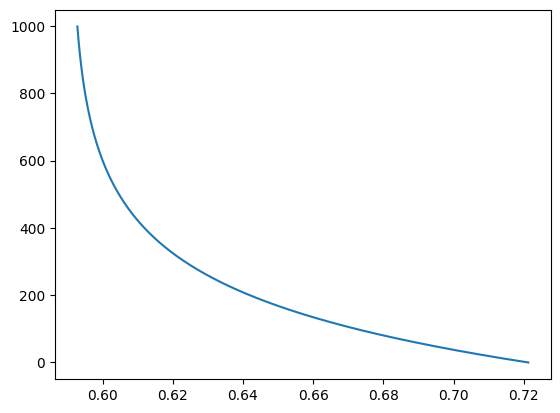

In [105]:
plt.plot(loss_list, epoch_list)

In [106]:
x_np = x.numpy()
y_np = y.numpy()
y_train_np = y_train.detach().numpy()
y1_np = y1.numpy()
y_test_np = y_test.detach().numpy()

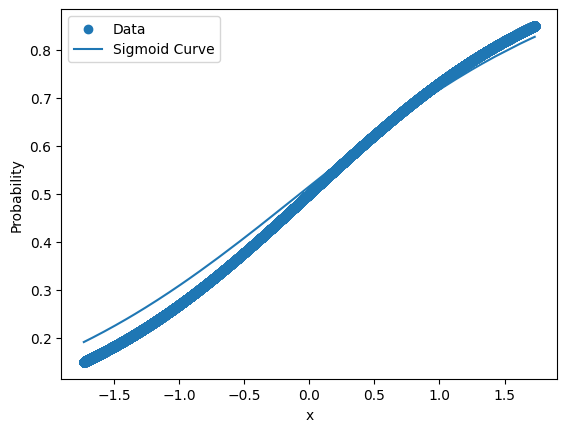

In [107]:
plt.scatter(x_np, y_np, label="Data")

plt.plot(x_np, y_train_np, label="Sigmoid Curve")

plt.xlabel("x")
plt.ylabel("Probability")

plt.legend()

plt.show()